In [1]:
import pandas as pd

In [2]:
image = pd.read_parquet(rf"/data/susanket/vlm/images3/image-00.parquet")

In [3]:
image

,group_id,is_multi_group,zoom,release_id,year,tile_lat,tile_lon,file_name,image_bytes,cloud_pct,entropy
0,f18073a7-9fb9-4360-97e9-723d776a0aee,False,19,22252,2025,40.943861,-85.335274,22252_19_137865_196677,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01...,0.012207,6.618519
1,14b6b960-b033-4571-a85b-91a6225ca8f0,False,19,22252,2025,32.056100,120.240211,22252_19_437256_212813,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.502014,7.371440
2,649c9097-fa76-4cac-936a-45e74379444c,False,19,13192,2025,-32.007203,115.768776,13192_19_430744_311390,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.355530,7.426975
3,0db4414c-5a7a-4272-894e-9b73e47110bf,False,19,22252,2025,30.998506,121.342964,22252_19_438862_214620,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.382996,6.980396
4,c5cbdeb6-8454-487e-b330-18a7633d9bfb,False,19,51127,2025,30.137705,31.450768,51127_19_307947_216076,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.038147,6.978867
...,...,...,...,...,...,...,...,...,...,...,...
999995,d15b120e-51df-4048-a392-92f686d71742,True,18,26334,2026,51.647424,5.401840,26334_18_135005_87005,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01...,0.154114,6.778941
999996,3484bdfa-927a-4bd6-8c97-0a3f20251b09,True,18,239,2018,-28.252981,129.988174,239_18_225726_152533,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.253296,7.414992
999997,fa4fd988-5e80-46a2-bf62-aec444bedad7,True,18,26334,2026,31.691366,34.912491,26334_18_156494_106719,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,6.949199
999998,80aee61b-ac4e-41d9-bd72-45059abdada8,True,18,26334,2026,26.729053,85.880814,26334_18_193608_110861,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,6.266753


In [4]:
image.zoom.unique()

array([19, 17, 18, 20], dtype=int32)

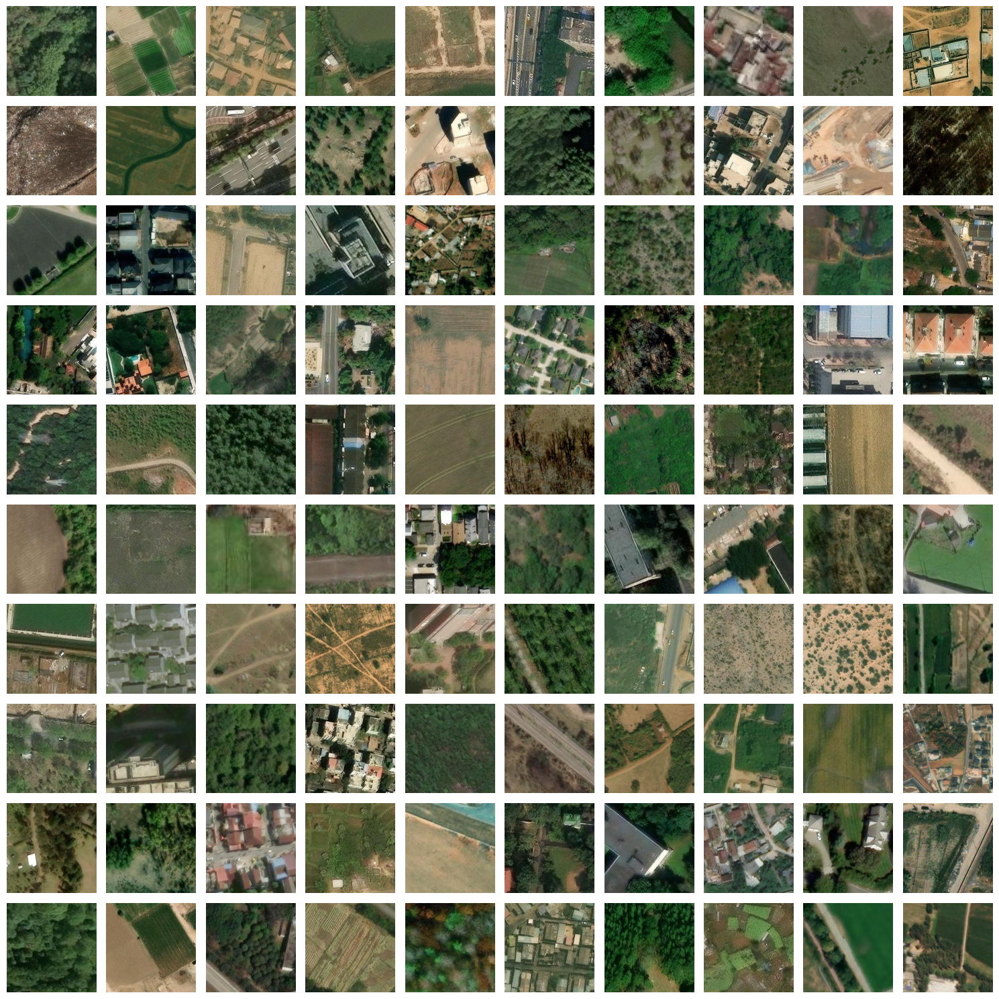

In [5]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Code snippet for the user:
sample_df = image.sample(n=min(100, len(image)))

fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for ax, img_bytes in zip(axes.flat, sample_df['image_bytes']):
    img = Image.open(io.BytesIO(img_bytes))
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
caption = pd.read_parquet(rf"/data/susanket/vlm/captions/caption-02.parquet")
caption = caption.rename(columns={"id": "file_name"})

In [14]:
caption

,file_name,scene_caption,spatial_dense_caption,keywords
0,26334_18_189953_112272,The image depicts a rural agricultural landsca...,"The image shows a roughly rectangular, elongat...","cultivated fields, irrigation canals, rectangu..."
1,26334_18_185120_113389,The image depicts a rural agricultural landsca...,A dark linear structure runs diagonally from t...,unclear image
2,26334_18_189533_126532,The image depicts a mix of dense forest cover ...,A prominent linear dark structure runs diagona...,"dense forest, open field, dirt road, small cle..."
3,26334_18_195610_113146,The image depicts a rural agricultural landsca...,The image displays a patchwork of cultivated f...,unclear image
4,26334_18_189786_118800,The image depicts a predominantly agricultural...,The image displays a patchwork of agricultural...,"cultivated fields, bare soil patches, dense fo..."
...,...,...,...,...
644679,26334_18_222410_125782,"The image depicts a densely vegetated, hilly o...",The image displays a patchwork of irregularly ...,unclear image
644680,26334_18_79022_97340,The image depicts a semi-urbanized area surrou...,A prominent dark-roofed structure is positione...,unclear image
644681,26334_18_219762_134016,The image depicts a predominantly agricultural...,The image displays a patchwork of cultivated f...,"agricultural fields, cultivated patches, fallo..."
644682,26334_18_208935_113126,"The image depicts a densely vegetated, likely ...",The image displays a patchwork of irregularly ...,unclear image


In [6]:
import io
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

image = pd.read_parquet(rf"/data/susanket/vlm/images3/image-00.parquet")
caption = pd.read_parquet(rf"/data/susanket/vlm/images3/caption-00.parquet")
caption = caption.rename(columns={"id": "file_name"})

# 1. Merge both DataFrames on 'file_name' and pick 10 random samples
# (Assuming your captions DF has 'id' renamed or aligned to 'file_name')
merged_df = pd.merge(image, caption, on="file_name")

In [13]:
caption = pd.read_parquet(rf"/data/susanket/vlm/images3/caption-00.parquet")
caption

,file_name,status,error,summary,dense_caption,key_elements
0,22252_19_137865_196677,ok,NaN,An aerial view of a forest with a narrow path ...,The image shows a dense forest with numerous t...,"[forest, path, river, trees, greenery, contras..."
1,22252_19_437256_212813,ok,NaN,"An aerial view of a property with a pool, buil...",The image shows a property with a rectangular ...,"[pool, dark building, road, vehicle, trees, sh..."
2,13192_19_430744_311390,ok,NaN,An aerial view of a road with surrounding gree...,"The image shows a road curving to the right, b...","[road, grass, trees, parking area, vehicles, d..."
3,22252_19_438862_214620,ok,NaN,An aerial view of a bridge over a body of wate...,The image shows a bridge spanning across a bod...,"[bridge, water, green fields, small structure,..."
4,51127_19_307947_216076,ok,NaN,An aerial view of a construction site with a l...,The image shows an aerial view of a constructi...,"[dirt area, building, small structure, road, p..."
...,...,...,...,...,...,...
999995,26334_18_135005_87005,ok,NaN,An aerial view of a rural property with a buil...,The image shows a large green field on the lef...,"[green field, dirt road, rectangular building,..."
999996,239_18_225726_152533,ok,NaN,An aerial view of a landscape with scattered v...,The image shows a vast area with a mix of dark...,"[vegetation patches, brown ground, small stone..."
999997,26334_18_156494_106719,ok,NaN,An aerial view of a dirt road flanked by green...,The image shows a dirt road running vertically...,"[dirt road, green grass, trees, vegetation]"
999998,26334_18_193608_110861,ok,NaN,An aerial view of a rural landscape with field...,The image shows a patchwork of agricultural fi...,"[fields, trees, water bodies, paths, roads]"


In [7]:
merged_df

,group_id,is_multi_group,zoom,release_id,year,tile_lat,tile_lon,file_name,image_bytes,cloud_pct,entropy,status,error,summary,dense_caption,key_elements
0,f18073a7-9fb9-4360-97e9-723d776a0aee,False,19,22252,2025,40.943861,-85.335274,22252_19_137865_196677,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01...,0.012207,6.618519,ok,NaN,An aerial view of a forest with a narrow path ...,The image shows a dense forest with numerous t...,"[forest, path, river, trees, greenery, contras..."
1,14b6b960-b033-4571-a85b-91a6225ca8f0,False,19,22252,2025,32.056100,120.240211,22252_19_437256_212813,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.502014,7.371440,ok,NaN,"An aerial view of a property with a pool, buil...",The image shows a property with a rectangular ...,"[pool, dark building, road, vehicle, trees, sh..."
2,649c9097-fa76-4cac-936a-45e74379444c,False,19,13192,2025,-32.007203,115.768776,13192_19_430744_311390,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.355530,7.426975,ok,NaN,An aerial view of a road with surrounding gree...,"The image shows a road curving to the right, b...","[road, grass, trees, parking area, vehicles, d..."
3,0db4414c-5a7a-4272-894e-9b73e47110bf,False,19,22252,2025,30.998506,121.342964,22252_19_438862_214620,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.382996,6.980396,ok,NaN,An aerial view of a bridge over a body of wate...,The image shows a bridge spanning across a bod...,"[bridge, water, green fields, small structure,..."
4,c5cbdeb6-8454-487e-b330-18a7633d9bfb,False,19,51127,2025,30.137705,31.450768,51127_19_307947_216076,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.038147,6.978867,ok,NaN,An aerial view of a construction site with a l...,The image shows an aerial view of a constructi...,"[dirt area, building, small structure, road, p..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,d15b120e-51df-4048-a392-92f686d71742,True,18,26334,2026,51.647424,5.401840,26334_18_135005_87005,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01...,0.154114,6.778941,ok,NaN,An aerial view of a rural property with a buil...,The image shows a large green field on the lef...,"[green field, dirt road, rectangular building,..."
999996,3484bdfa-927a-4bd6-8c97-0a3f20251b09,True,18,239,2018,-28.252981,129.988174,239_18_225726_152533,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.253296,7.414992,ok,NaN,An aerial view of a landscape with scattered v...,The image shows a vast area with a mix of dark...,"[vegetation patches, brown ground, small stone..."
999997,fa4fd988-5e80-46a2-bf62-aec444bedad7,True,18,26334,2026,31.691366,34.912491,26334_18_156494_106719,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,6.949199,ok,NaN,An aerial view of a dirt road flanked by green...,The image shows a dirt road running vertically...,"[dirt road, green grass, trees, vegetation]"
999998,80aee61b-ac4e-41d9-bd72-45059abdada8,True,18,26334,2026,26.729053,85.880814,26334_18_193608_110861,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,6.266753,ok,NaN,An aerial view of a rural landscape with field...,The image shows a patchwork of agricultural fi...,"[fields, trees, water bodies, paths, roads]"


In [ ]:
# merged_df = pd.merge(image, filtered, on="file_name")

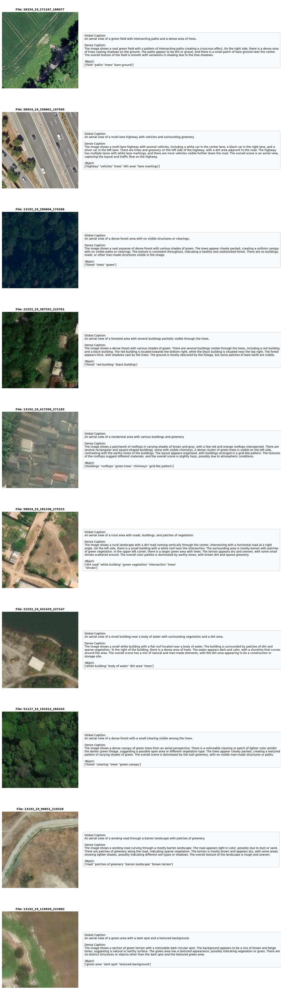

In [13]:
# 2. Setup grid layout (10 rows, 2 columns: Column 1 for image, Column 2 for text)
fig, axes = plt.subplots(10, 2, figsize=(14, 50), gridspec_kw={'width_ratios': [1, 2.2]})

# 3. Populate rows
for idx, (_, row) in enumerate(merged_df.sample(min(10, len(merged_df))).iterrows()):
    # Render Image
    img = Image.open(io.BytesIO(row["image_bytes"]))
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"File: {row['file_name']}", fontsize=10, fontweight="bold")
    axes[idx, 0].axis("off")

    # Format text card for captions
    caption_text = (
        f"Global Caption:\n{row['summary']}\n\n"
        f"Dense Caption:\n{row['dense_caption']}\n\n"
        f"Object:\n{row['key_elements']}"
    )

    # Render formatted text box next to image
    axes[idx, 1].text(
        0.02, 0.5, caption_text,
        fontsize=10,
        va="center",
        ha="left",
        wrap=True,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#f8f9fa", edgecolor="#d0d0d0")
    )
    axes[idx, 1].axis("off")

plt.tight_layout()
plt.show()

In [31]:
image = pd.read_parquet(rf"/data/susanket/vlm/images/image-02.parquet")

In [24]:
image[image["file_name"]=="26334_19_416196_230843"]['image_bytes'].iloc[0]

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x05\x03\x04\x04\x04\x03\x05\x04\x04\x04\x05\x05\x05\x06\x07\x0c\x08\x07\x07\x07\x07\x0f\x0b\x0b\t\x0c\x11\x0f\x12\x12\x11\x0f\x11\x11\x13\x16\x1c\x17\x13\x14\x1a\x15\x11\x11\x18!\x18\x1a\x1d\x1d\x1f\x1f\x1f\x13\x17"$"\x1e$\x1c\x1e\x1f\x1e\xff\xdb\x00C\x01\x05\x05\x05\x07\x06\x07\x0e\x08\x08\x0e\x1e\x14\x11\x14\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\xff\xc0\x00\x11\x08\x01\x00\x01\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x03\x01\x00\x03\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x05\x06\x07\x04\x02\x03\x08\x00\x01\xff\xc4\x00=\x10\x00\x01\x03\x03\x03\x02\x04\x04\x04\x05\x02\x06\x02\x03\x00\x00\x02\x03\x04\x12\x00\x05"\x062B\x13R\x01\x14br\x07#\x82\x92\x11\x15\xa2\xb2$3\xc2\xd2\xf0C\xe2\x16!14S\xf2%c&AD\xff\xc4\x00\x1b

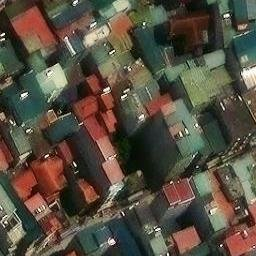

In [25]:
from PIL import Image 
import io

image_bytes = image[image["file_name"]=="26334_19_416196_230843"]['image_bytes'].iloc[0]
image = Image.open(io.BytesIO(image_bytes))
image.show()

In [26]:
caption[caption["file_name"]=="26334_19_416196_230843"]

,file_name,status,error,summary,dense_caption,key_elements
115,26334_19_416196_230843,ok,NaN,An aerial view of a densely packed urban area ...,The image shows a cluster of buildings with di...,"[red building, green building, brown building,..."


In [32]:
image

,group_id,is_multi_group,zoom,release_id,year,tile_lat,tile_lon,file_name,image_bytes,cloud_pct,entropy
0,6af2eb8b-7199-463a-85a5-83b787c1584d,False,18,26334,2026,33.651780,113.996201,26334_18_214081_105023,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.001526,6.263666
1,c913ec6d-2b8a-4e3a-89ae-7e56e6650512,False,18,26334,2026,40.055476,116.138535,26334_18_215641_99189,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.212097,6.650006
2,addef2ca-0f48-491e-a971-d1dd8e260a3b,False,18,26334,2026,30.717636,75.555038,26334_18_186089_107548,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,4.151918
3,6a53f93e-8a37-4022-b782-b48cc26e3807,False,18,26334,2026,21.543150,105.697403,26334_18_208038_115001,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,6.367885
4,f9f7f91d-3611-4a16-a100-ff7e06e98a5c,False,18,26334,2026,27.806891,85.323257,26334_18_193202_109978,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,6.282154
...,...,...,...,...,...,...,...,...,...,...,...
999995,62d0eb50-c2e8-4aad-8a32-3c713c79d1e5,False,18,26334,2026,10.312893,-69.232407,26334_18_80658_123521,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,6.368548
999996,97c5c38d-a421-418a-b2f7-87152ca13503,False,18,26334,2026,-2.108212,29.924698,26334_18_152862_132607,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,7.005150
999997,8763cf8a-2764-4f19-b2dc-b0e1b95180ee,False,18,26334,2026,-21.990805,-42.486191,26334_18_100134_147493,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,6.155113
999998,b1d35e79-c290-4094-a237-c47ca54835f7,False,18,26334,2026,33.840194,-117.801590,26334_18_45291_104858,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,1.782227,7.496301


---

### OSM

Fetching satellite tile (Zoom 17, X: 22361, Y: 52275) year 2026...


Fetching ALL OSM features (rivers, roads, buildings, parks)...


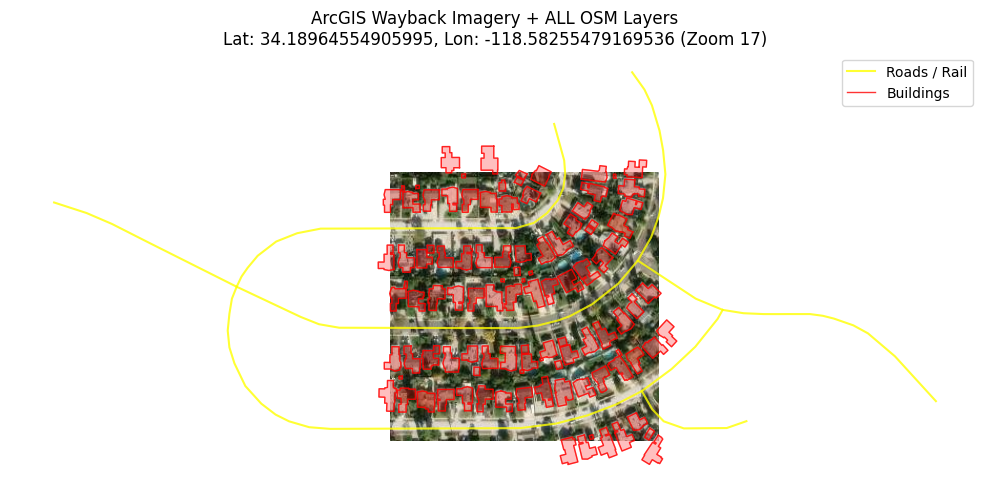

In [49]:
import math
from io import BytesIO
import matplotlib.pyplot as plt
from PIL import Image
import requests

WAYBACK_RELEASES = {
    3026: 2014,
    239: 2018,
    45134: 2022,
    26334: 2026,
}

TILE_URL_TMPL = (
    "https://wayback.maptiles.arcgis.com/arcgis/rest/services/World_Imagery/"
    "WMTS/1.0.0/default028mm/MapServer/tile/{release_id}/{zoom}/{y}/{x}"
)


def latlon_to_tile(lat: float, lon: float, zoom: int):
    """Convert lat/lon to Web Mercator tile (x, y)."""
    lat_rad = math.radians(lat)
    n = 2.0**zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return xtile, ytile


def tile_bounds(x: int, y: int, zoom: int):
    """Calculate geographic bounding box for tile."""
    n = 2.0**zoom
    lon_min = x / n * 360.0 - 180.0
    lon_max = (x + 1) / n * 360.0 - 180.0
    lat_max = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))
    lat_min = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * (y + 1) / n))))
    return lon_min, lat_min, lon_max, lat_max


def fetch_tile_image(release_id: int, zoom: int, x: int, y: int) -> Image.Image:
    """Fetch imagery tile from Esri Wayback service."""
    url = TILE_URL_TMPL.format(release_id=release_id, zoom=zoom, x=x, y=y)
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")


def fetch_all_osm_features(bbox: tuple):
    """Fetch EVERYTHING inside the bounding box from OpenStreetMap."""
    min_lon, min_lat, max_lon, max_lat = bbox

    # Query for ALL nodes, ways, and relations inside bbox
    query = f"""
    [out:json][timeout:30];
    (
      nwr({min_lat},{min_lon},{max_lat},{max_lon});
    );
    out body;
    >;
    out skel qt;
    """

    headers = {
        "User-Agent": "FullOSMPlotter/1.0 (Python Script)",
        "Content-Type": "application/x-www-form-urlencoded; charset=UTF-8",
    }

    overpass_endpoints = [
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
        "https://maps.mail.ru/osm/tools/overpass/api/interpreter",
    ]

    response = None
    for endpoint in overpass_endpoints:
        try:
            response = requests.post(
                endpoint, data={"data": query}, headers=headers, timeout=35
            )
            if response.status_code == 200:
                break
        except requests.RequestException:
            continue

    if not response or response.status_code != 200:
        raise RuntimeError("Failed to fetch data from Overpass API.")

    data = response.json()

    # Build node mapping for geometry reconstruction
    nodes = {
        element["id"]: (element["lon"], element["lat"])
        for element in data.get("elements", [])
        if element["type"] == "node"
    }

    # Categorize elements into feature layers
    layers = {"water": [], "roads": [], "buildings": [], "parks": [], "other": []}

    for element in data.get("elements", []):
        if element["type"] == "way":
            way_nodes = element.get("nodes", [])
            coords = [nodes[nid] for nid in way_nodes if nid in nodes]
            if not coords:
                continue

            tags = element.get("tags", {})

            # 1. Rivers & Water bodies
            if "waterway" in tags or "natural" in tags and tags["natural"] == "water":
                layers["water"].append(coords)
            # 2. Roads, Streets & Railways
            elif "highway" in tags or "railway" in tags:
                layers["roads"].append(coords)
            # 3. Buildings
            elif "building" in tags:
                layers["buildings"].append(coords)
            # 4. Parks, Forests & Greenery
            elif (
                tags.get("leisure") == "park"
                or tags.get("landuse") in ["grass", "forest", "meadow"]
            ):
                layers["parks"].append(coords)
            else:
                layers["other"].append(coords)

    return layers


def lonlat_to_pixel(
    lon: float, lat: float, bbox: tuple, img_width: int = 256, img_height: int = 256
):
    """Project coordinate to pixel space on tile."""
    min_lon, min_lat, max_lon, max_lat = bbox
    px = (lon - min_lon) / (max_lon - min_lon) * img_width
    py = (max_lat - lat) / (max_lat - min_lat) * img_height
    return px, py


def visualize_tile_with_full_osm(
    lat: float, lon: float, zoom: int = 18, release_id: int = 26334
):
    """Fetch satellite imagery and plot ALL OSM layers on top."""
    x, y = latlon_to_tile(lat, lon, zoom)
    bbox = tile_bounds(x, y, zoom)

    print(
        f"Fetching satellite tile (Zoom {zoom}, X: {x}, Y: {y}) year {WAYBACK_RELEASES.get(release_id)}..."
    )
    tile_img = fetch_tile_image(release_id, zoom, x, y)

    print("Fetching ALL OSM features (rivers, roads, buildings, parks)...")
    layers = fetch_all_osm_features(bbox)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(tile_img)

    # 1. Plot Parks / Greenery (Green fill)
    for coords in layers["parks"]:
        pxs, pys = zip(*[lonlat_to_pixel(c[0], c[1], bbox) for c in coords])
        ax.fill(pxs, pys, color="limegreen", alpha=0.35, label="Parks / Greenery")

    # 2. Plot Rivers / Waterways (Blue line & fill)
    for coords in layers["water"]:
        pxs, pys = zip(*[lonlat_to_pixel(c[0], c[1], bbox) for c in coords])
        ax.plot(
            pxs,
            pys,
            color="deepskyblue",
            linewidth=3,
            alpha=0.9,
            label="Rivers / Water",
        )
        ax.fill(pxs, pys, color="deepskyblue", alpha=0.3)

    # 3. Plot Roads & Railways (Yellow line)
    for coords in layers["roads"]:
        pxs, pys = zip(*[lonlat_to_pixel(c[0], c[1], bbox) for c in coords])
        ax.plot(
            pxs, pys, color="yellow", linewidth=1.5, alpha=0.8, label="Roads / Rail"
        )

    # 4. Plot Buildings (Cyan outline & fill)
    for coords in layers["buildings"]:
        pxs, pys = zip(*[lonlat_to_pixel(c[0], c[1], bbox) for c in coords])
        ax.plot(
            pxs,
            pys,
            color="red",
            linewidth=1.0,
            alpha=0.8,
            label="Buildings",
        )
        ax.fill(pxs, pys, color="red", alpha=0.25)

    # Clean up duplicate labels in legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        ax.legend(by_label.values(), by_label.keys(), loc="upper right")

    ax.set_title(
        f"ArcGIS Wayback Imagery + ALL OSM Layers\nLat: {lat}, Lon: {lon} (Zoom {zoom})"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# --- Example Run ---
if __name__ == "__main__":
    # Coordinates near London Eye / River Thames
    sample_lat, sample_lon = 34.18964554905995, -118.58255479169536
    visualize_tile_with_full_osm(
        lat=sample_lat, lon=sample_lon, zoom=17, release_id=26334
    )

### Visualize single keywords

In [ ]:
import pandas as pd

df = pd.read_parquet(rf"fact chnage")
image = pd.read_parquet(rf"/data/susanket/vlm/images2/tbd.parquet")


In [34]:
df

,file_name,status,error,summary,dense_caption,key_elements
0,3026_17_90701_52107,ok,NaN,An aerial view of a densely packed urban area ...,The image shows a large complex of buildings w...,"[beige building, brown building, blue rooftop,..."
1,239_18_70412_104707,ok,NaN,An aerial view of a residential area with vari...,The image shows a residential area with severa...,"[road, red building, black building, white bui..."
2,45134_17_92683_53631,ok,NaN,An aerial view of a rural landscape with field...,The image shows a patchwork of green fields an...,"[fields, trees, small structure, dirt paths, f..."
3,239_18_134180_86676,ok,NaN,"An aerial view of a road with vehicles, a rive...","The image shows a road with multiple vehicles,...","[road, vehicles, river, building, parking area..."
4,3026_17_81460_51838,ok,NaN,An aerial view of a desert landscape with a ro...,The image shows a desert landscape with sandy ...,"[road, vehicle, desert, tire tracks]"
...,...,...,...,...,...,...
4995,45134_18_90272_142632,ok,NaN,An aerial view of a dense forest with a dirt p...,The image shows a dense forest with lush green...,"[forest, dirt path, barren area]"
4996,26334_17_109696_54152,ok,NaN,An aerial view of a densely built urban area w...,The image shows a cluster of buildings with va...,"[river, bridge, red building, gray building, n..."
4997,26334_18_156676_106000,ok,NaN,An aerial view of a residential area with vari...,The image shows a cluster of buildings surroun...,"[white building, red building, black building,..."
4998,26334_18_141725_123864,ok,NaN,An aerial view of a landscape with scattered v...,The image shows a vast expanse of land with pa...,"[vegetation, pathways, land, green, brown]"


In [43]:
# Returns True if the word is found in ANY row of 'column_name'
df['summary'].str.contains('solar', na=False)


0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Name: summary, Length: 5000, dtype: bool

In [14]:
# Returns a filtered DataFrame containing only the matching rows
filtered = merged_df[merged_df['summary'].str.contains('solar', na=False)]


In [15]:
filtered

,group_id,is_multi_group,zoom,release_id,year,tile_lat,tile_lon,file_name,image_bytes,cloud_pct,entropy,status,error,summary,dense_caption,key_elements
1165,6f3a6ce9-ea3c-4460-9b47-aa09ae25e752,False,19,22252,2025,31.450046,74.456749,22252_19_370579_213851,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.112915,7.228946,ok,NaN,An aerial view of a building with solar panels...,The image shows a building with a slanted roof...,"[solar panels, building, road, trees, field]"
1664,09e97fab-cd73-4d47-9e26-129bdb703013,False,19,13192,2025,31.467618,121.305885,13192_19_438808_213821,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.010681,6.743989,ok,NaN,An aerial view of a green field with a solar p...,The image shows a large green field with a dis...,"[green field, solar panels, water body]"
1805,ec631946-ef46-4b1e-8654-6e4696b2539e,False,19,51127,2025,30.740360,76.708946,51127_19_373859_215058,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,1.705933,6.490126,ok,NaN,An aerial view of a forested area with a struc...,The image shows a dense forest with various sh...,"[forest, solar panels]"
2055,29e846bc-64fe-463a-903e-41218a838f5e,False,19,22252,2025,52.094062,8.680229,22252_19_274785_172957,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,2.934265,7.246805,ok,NaN,An aerial view of a rooftop with solar panels ...,The image shows a rooftop covered with solar p...,"[solar panels, pavement, dark objects]"
2660,17a71fc0-4315-4d8e-83d3-19ecc5904532,False,19,26334,2025,22.714440,114.149666,26334_19_428386_228161,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,1.945496,7.080955,ok,NaN,An aerial view of a parking lot with solar pan...,The image shows a parking lot with several car...,"[solar panels, red building, black building, p..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987882,7c10632b-fa1e-4d9d-8a0d-4ed67b3596b1,True,18,45134,2022,32.668859,-115.662003,45134_18_46849_105878,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.260925,6.417451,ok,NaN,An aerial view of a solar panel field with a s...,The image shows a large expanse of solar panel...,"[solar panels, white vehicle, path]"
988521,b9bc19fb-a533-4177-acbe-7afe21df3374,True,17,26334,2026,17.817993,74.527130,26334_17_92670_58941,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.019836,6.696958,ok,NaN,An aerial view of a solar farm with multiple r...,The image shows an aerial view of a large sola...,"[solar panels, buildings, dry ground, greenery]"
988524,b9bc19fb-a533-4177-acbe-7afe21df3374,True,18,26334,2026,17.817340,74.527817,26334_18_185341_117883,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0.000000,6.516633,ok,NaN,An aerial view of a solar farm with multiple r...,The image shows an aerial view of a large sola...,"[solar panels, small building, blue roof, dry ..."
989338,1b1648e4-6f40-4c9d-923b-ce05f41b8726,True,17,45134,2022,-34.616257,-58.607941,45134_17_44197_78984,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01...,2.789307,6.563747,ok,NaN,An aerial view of a road and agricultural fiel...,"The image shows a long, straight road running ...","[road, fields, solar panels]"


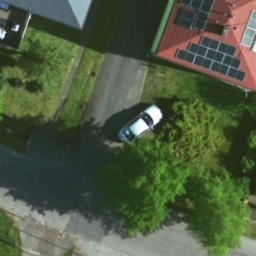

In [ ]:
# from PIL import Image 
# import io

# row = image.loc[image['file_name']=="26334_20_580076_354764"].index
# image_bytes = image.at[row[0], 'image_bytes']
# image = Image.open(io.BytesIO(image_bytes))
# image.show()

Visualize a speciifc keyword

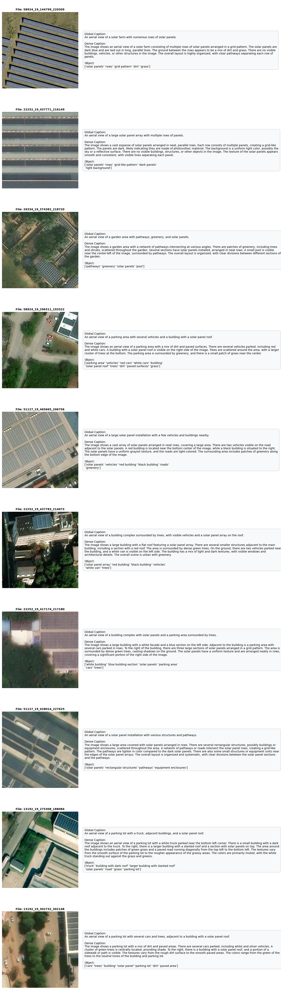

In [19]:
# 2. Setup grid layout (10 rows, 2 columns: Column 1 for image, Column 2 for text)
fig, axes = plt.subplots(10, 2, figsize=(14, 50), gridspec_kw={'width_ratios': [1, 2.2]})

# 3. Populate rows
for idx, (_, row) in enumerate(filtered.sample(min(10, len(filtered))).iterrows()):
    # Render Image
    img = Image.open(io.BytesIO(row["image_bytes"]))
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"File: {row['file_name']}", fontsize=10, fontweight="bold")
    axes[idx, 0].axis("off")

    # Format text card for captions
    caption_text = (
        f"Global Caption:\n{row['summary']}\n\n"
        f"Dense Caption:\n{row['dense_caption']}\n\n"
        f"Object:\n{row['key_elements']}"
    )

    # Render formatted text box next to image
    axes[idx, 1].text(
        0.02, 0.5, caption_text,
        fontsize=10,
        va="center",
        ha="left",
        wrap=True,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#f8f9fa", edgecolor="#d0d0d0")
    )
    axes[idx, 1].axis("off")

plt.tight_layout()
plt.show()

### Masks

In [7]:
import os
import io
import re
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# --- Configuration & Paths ---
IMAGES_PARQUET = r"/data/susanket/vlm/images3/image-00.parquet"
CAPTIONS_PARQUET = r"/data/susanket/vlm/images3/caption-00.parquet"
OUTPUT_MASK_DIR = r"/data/susanket/vlm/images3/masks/mask-00"
OUTPUT_SAVED_PLOT = "mask_collages.png"

# Compiled regex to quickly parse saved keyword strings if needed
KEYWORD_REGEX = re.compile(r"'(.*?)'")


def create_mask_collages(
    parquet_path: str, captions_path: str, mask_dir: str, n: int = 5
):
    print("Loading Parquet files...")
    img_df = pd.read_parquet(parquet_path)
    cap_df = pd.read_parquet(captions_path).rename(columns={"id": "file_name"})
    df = pd.merge(img_df, cap_df, on="file_name")

    # Filter to only images that actually have a saved .npy mask file
    valid_rows = []
    for idx, row in df.iterrows():
        file_name = str(row["file_name"])
        base_name = os.path.splitext(os.path.basename(file_name))[0]
        npy_path = os.path.join(mask_dir, f"{base_name}.npy")

        if os.path.exists(npy_path):
            valid_rows.append((row, npy_path))

    if not valid_rows:
        print(f"No matching .npy mask files found in '{mask_dir}'.")
        return

    # Pick N random samples from valid rows
    sampled = random.sample(valid_rows, min(n, len(valid_rows)))
    print(f"Generating collage for {len(sampled)} random images...")

    # Create Matplotlib grid: N rows, 2 columns (Original | Mask Overlay)
    fig, axes = plt.subplots(len(sampled), 2, figsize=(10, 4 * len(sampled)))
    if len(sampled) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (row, npy_path) in enumerate(sampled):
        file_name = str(row["file_name"])
        raw_keywords = str(row.get("key_elements", ""))
        keywords = KEYWORD_REGEX.findall(raw_keywords)

        # 1. Load Original Image
        img_bytes = row["image_bytes"]
        image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        img_np = np.array(image)

        # 2. Load 3D Stacked Binary Mask Array: shape (N_masks, H, W)
        masks_array = np.load(npy_path)

        # Combine all masks into a single 2D composite visualization
        if masks_array.ndim == 3:
            # Assign distinct intensity values per mask layer
            composite_mask = np.zeros(
                (masks_array.shape[1], masks_array.shape[2]), dtype=np.float32
            )
            for idx in range(masks_array.shape[0]):
                composite_mask[masks_array[idx]] = idx + 1
        else:
            composite_mask = masks_array.astype(np.float32)

        # --- Subplot 1: Original Image ---
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"Original: {os.path.basename(file_name)}")
        axes[i, 0].axis("off")

        # --- Subplot 2: Overlay Mask ---
        axes[i, 1].imshow(img_np)
        # Overlay non-zero mask pixels using a semi-transparent 'jet' or 'viridis' colormap
        masked_composite = np.ma.masked_where(
            composite_mask == 0, composite_mask
        )
        axes[i, 1].imshow(
            masked_composite, cmap="tab10", alpha=0.6, interpolation="none"
        )

        kw_title = ", ".join(keywords[:5]) if keywords else "Mask Overlay"
        axes[i, 1].set_title(f"Masks ({len(masks_array)}): {kw_title}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    # plt.savefig(OUTPUT_SAVED_PLOT, dpi=150, bbox_inches="tight")
    # print(f"Collage saved successfully to '{OUTPUT_SAVED_PLOT}'.")
    plt.show()

Loading Parquet files...


Generating collage for 15 random images...


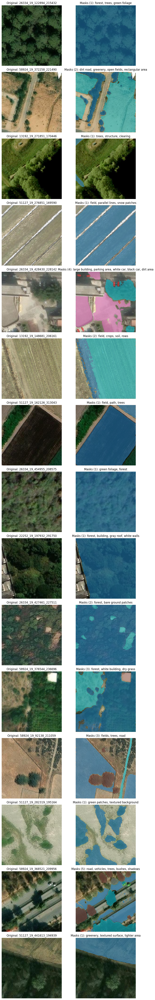

In [19]:
create_mask_collages(
    IMAGES_PARQUET, CAPTIONS_PARQUET, OUTPUT_MASK_DIR, n=15
)

In [20]:
import pandas as pd

df = pd.read_csv(rf"/data/susanket/vlm/images3/masks/mask-00.csv")

In [21]:
df

,file_name,key_elements
0,22252_19_137865_196677,"forest, trees"
1,22252_19_437256_212813,"road, shrubs"
2,13192_19_430744_311390,"road, grass, trees"
3,22252_19_438862_214620,"bridge, green fields, small structure"
4,51127_19_307947_216076,"dirt area, small structure"
...,...,...
481,51127_19_274503_189559,forest
482,22252_19_373889_215013,"building, trees, field, green area"
483,58924_19_374803_218579,"greenery, trees, bushes"
484,26334_19_249770_196480,"green vegetation, brown terrain"


In [22]:
len(os.listdir(rf"/data/susanket/vlm/images3/masks/mask-00"))

101611